In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ARTIFACTS_PUBLIC = PROJECT_ROOT / "artifacts" / "public"
DATA_PUBLIC = PROJECT_ROOT / "data" / "public"
MODELS_PUBLIC = PROJECT_ROOT / "models" / "public"

# Notebook de KNN

Este es el notebook 01 del proyecto `Recommend Supplier`.

- En este notebook construimos el baseline con `KNN` (`KNeighborsClassifier`) para tener una primera referencia de rendimiento.
- `KNN` clasifica por similitud entre observaciones; en esta versión trabajamos con distancia euclídea (Minkowski `p=2`) tras el preprocesado correspondiente.
- El objetivo aquí no es cerrar el modelo final, sino evaluar si `KNN` aporta señal frente a baselines en validación temporal.
- El proceso de ETL se desarrolló con asistencia de IA por el volumen y heterogeneidad de fuentes, y está documentado para su trazabilidad en `plan_etl.md` y en `src/etl/`.

Por privacidad, el repositorio público no incluye `raw data` ni piezas sensibles de extracción.

## Librerías

In [2]:
# Librerías

import pandas as pd
pd.set_option("display.max_columns", None)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score

# Sube de notebooks/ a la raíz del repo

sys.path.append(str(Path.cwd().parent))

# Importamos funciones

import src.ml.shared.functions as fc

%matplotlib inline 
%load_ext autoreload
%autoreload 2


## Cargamos dataset

In [3]:
df = fc.load_data("dataset_modelo_proveedor_v1.csv")

## Exploramos

In [4]:
df.head()

,fecha_compra,albaran_id,linea_id,producto_canonico,terminal_canonico,proveedor_canonico,litros,precio_unitario,importe_total,coste_min_dia_proveedor,rank_coste_dia_producto,terminales_cubiertos,feature_oferta_disponible,dia_semana,mes,fin_mes,blocked_by_rule,block_reason,proveedor_elegido,source_file,source_transform_run_id,marts_run_id,marts_ts_utc
0,2021-04-03,ALBARAN_D7E0C13BBBBC,LINE_0CBDAF1D1C30,PRODUCT_002,TERMINAL_001,SUPPLIER_009,9999,0.79428,7942.01,799.35,6.0,4.0,1,0,4,0,0,NaN,SUPPLIER_009,SOURCE_3EF4FA15DAD7,RUN_F9DD4879EEBD,RUN_060EECAEE61E,2030-02-23T13:50:24Z
1,2021-04-03,ALBARAN_D7E0C13BBBBC,LINE_07771A799E32,PRODUCT_002,TERMINAL_001,SUPPLIER_009,4999,0.79428,3970.61,799.35,6.0,4.0,1,0,4,0,0,NaN,SUPPLIER_009,SOURCE_3EF4FA15DAD7,RUN_F9DD4879EEBD,RUN_060EECAEE61E,2030-02-23T13:50:24Z
2,2021-04-03,ALBARAN_D7E0C13BBBBC,LINE_4B983CB16D58,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1999,0.47957,958.66,489.29,10.0,4.0,1,0,4,0,0,NaN,SUPPLIER_009,SOURCE_3EF4FA15DAD7,RUN_F9DD4879EEBD,RUN_060EECAEE61E,2030-02-23T13:50:24Z
3,2021-04-03,ALBARAN_D7E0C13BBBBC,LINE_ECBE43367EA4,PRODUCT_003,TERMINAL_001,SUPPLIER_009,13001,0.47957,6234.89,489.29,10.0,4.0,1,0,4,0,0,NaN,SUPPLIER_009,SOURCE_3EF4FA15DAD7,RUN_F9DD4879EEBD,RUN_060EECAEE61E,2030-02-23T13:50:24Z
4,2021-04-03,ALBARAN_D7E0C13BBBBC,LINE_06CBC590750C,PRODUCT_003,TERMINAL_001,SUPPLIER_009,1999,0.47957,958.66,489.29,10.0,4.0,1,0,4,0,0,NaN,SUPPLIER_009,SOURCE_3EF4FA15DAD7,RUN_F9DD4879EEBD,RUN_060EECAEE61E,2030-02-23T13:50:24Z


In [5]:
# Ordenamos por fecha

df["fecha_compra"] = pd.to_datetime(df["fecha_compra"], format="%Y-%m-%d", errors="coerce")
df = df.sort_values("fecha_compra")

### Shape, dtypes, datos perdidos

In [6]:
df.shape

(16315, 23)

In [7]:
df.dtypes

fecha_compra                 datetime64[ns]
albaran_id                           object
linea_id                             object
producto_canonico                    object
terminal_canonico                    object
proveedor_canonico                   object
litros                                int64
precio_unitario                     float64
importe_total                       float64
coste_min_dia_proveedor             float64
rank_coste_dia_producto             float64
terminales_cubiertos                float64
feature_oferta_disponible             int64
dia_semana                            int64
mes                                   int64
fin_mes                               int64
blocked_by_rule                       int64
block_reason                        float64
proveedor_elegido                    object
source_file                          object
source_transform_run_id              object
marts_run_id                         object
marts_ts_utc                    

In [8]:
df.isna().sum()

fecha_compra                     0
albaran_id                       0
linea_id                         0
producto_canonico                0
terminal_canonico                0
proveedor_canonico               0
litros                           0
precio_unitario                  0
importe_total                    0
coste_min_dia_proveedor        907
rank_coste_dia_producto        907
terminales_cubiertos           907
feature_oferta_disponible        0
dia_semana                       0
mes                              0
fin_mes                          0
blocked_by_rule                  0
block_reason                 16315
proveedor_elegido                0
source_file                      0
source_transform_run_id          0
marts_run_id                     0
marts_ts_utc                     0
dtype: int64

### Subset de entrenamiento sin datos perdidos

- Elegimos rellenar los datos perdidos numéricos e ignorar los que no.

In [9]:
df_model = fc.df_model_knn(df)

## KNN

In [10]:
X, y = fc.seleccionar_feature_cols(df_model)
X.shape, y.shape

((15408, 7), (15408,))

### Train Test Split

- Temporal

In [11]:
# Hago split temporal con función para enternar el modelo

X_train, X_test, y_train, y_test = fc.split_temporal(df_model)

In [12]:
# Entrena KNN y genera predicciones explícitas (reproducible)

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
])

knn.fit(X_train, y_train)
pred = knn.predict(X_test)
knn_acc = knn.score(X_test, y_test)
knn_acc


0.545425048669695

In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score

dummy = DummyClassifier(strategy="most_frequent", random_state=0).fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
labels_eval = np.union1d(y_test, pred)
labels_present_test = np.unique(y_test)

print(f"Dummy Accuracy (baseline de clase mayoritaria): {accuracy_score(y_test, dummy_pred):.4f}")
print(f"KNN Accuracy (acierto global): {accuracy_score(y_test, pred):.4f}")
print(f"KNN F1 Weighted (F1 ponderado por soporte de clase): {f1_score(y_test, pred, labels=labels_eval, average='weighted', zero_division=0):.4f}")
print(f"KNN Balanced Accuracy (media de recall por clase): {recall_score(y_test, pred, labels=labels_present_test, average='macro', zero_division=0):.4f}")


Dummy Accuracy (baseline de clase mayoritaria): 0.7677
KNN Accuracy (acierto global): 0.5454
KNN F1 Weighted (F1 ponderado por soporte de clase): 0.6140
KNN Balanced Accuracy (media de recall por clase): 0.1297


## Cierre Day 01 (Baseline)

### Dataset y split
- Dataset usado: `data/public/dataset_modelo_proveedor_v1.csv`.
- Este dataset contiene una fila por compra real (`fecha_compra` + proveedor elegido) y se usó para el baseline inicial de clasificación multiclase de proveedor.
- No contiene el universo completo de proveedores no elegidos por evento (eso se aborda en V2 candidates con otros modelos que lo soportan mejor).
- Split temporal: `train=12326`, `test=3082` (80/20 por orden temporal sobre filas modelables).

### Resultados
- Dummy Accuracy (baseline clase mayoritaria): `0.7677`
- KNN Accuracy (k=5): `0.5454`
- KNN F1 Weighted (k=5): `0.6140`
- KNN Balanced Accuracy (k=5): `0.1297`

### Diagnóstico
- Existe desbalance de clases y fuerte concentración histórica en proveedor dominante.
- KNN no supera al baseline `Dummy` en este corte temporal.
- Conclusión Day 01: baseline operativo sigue siendo `Dummy` como referencia inicial.
- Riesgo principal: optimizar solo `accuracy` en un problema desbalanceado; probablemente otros modelos darán mejor resultado que este.

## VISUALIZACIONES

In [14]:

labels_eval = np.union1d(y_test, pred)
labels_present_test = np.unique(y_test)

metrics_df = pd.DataFrame([
    {
        "model": "Dummy",
        "accuracy": accuracy_score(y_test, dummy_pred),
        "f1_weighted": f1_score(y_test, dummy_pred, labels=labels_eval, average="weighted", zero_division=0),
        "balanced_accuracy": recall_score(y_test, dummy_pred, labels=labels_present_test, average="macro", zero_division=0),
    },
    {
        "model": "KNN (k=5)",
        "accuracy": accuracy_score(y_test, pred),
        "f1_weighted": f1_score(y_test, pred, labels=labels_eval, average="weighted", zero_division=0),
        "balanced_accuracy": recall_score(y_test, pred, labels=labels_present_test, average="macro", zero_division=0),
    },
])

metrics_df


,model,accuracy,f1_weighted,balanced_accuracy
0,Dummy,0.767683,0.666791,0.071429
1,KNN (k=5),0.545425,0.613968,0.129706


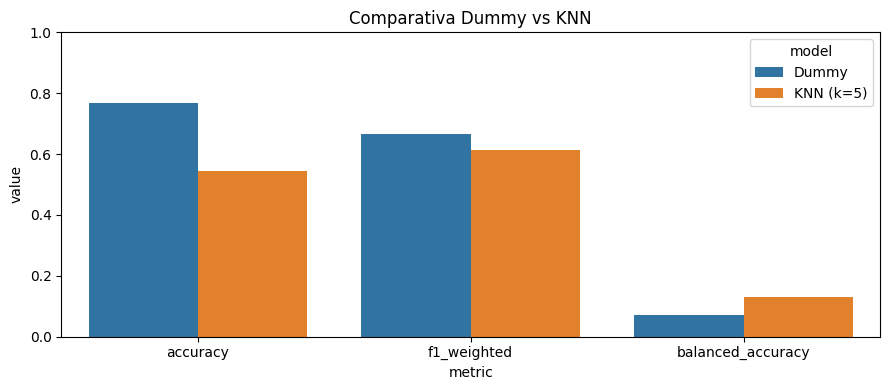

In [15]:
# BARPLOT COMPARACIÓN MODELOS

plot_df = metrics_df.melt(id_vars="model", var_name="metric", value_name="value")

plt.figure(figsize=(9, 4))
sns.barplot(data=plot_df, x="metric", y="value", hue="model")
plt.ylim(0, 1)
plt.title("Comparativa Dummy vs KNN")
plt.tight_layout()
plt.show()


In [16]:
# DESBALANCE

train_dist = pd.Series(y_train).value_counts(normalize=True).head(10).rename("train_ratio")
test_dist = pd.Series(y_test).value_counts(normalize=True).head(10).rename("test_ratio")

dist_df = pd.concat([train_dist, test_dist], axis=1).fillna(0).reset_index().rename(columns={"index": "proveedor"})
dist_df


,proveedor_elegido,train_ratio,test_ratio
0,SUPPLIER_009,0.539591,0.767683
1,SUPPLIER_050,0.278598,0.049968
2,SUPPLIER_010,0.049002,0.000000
3,SUPPLIER_020,0.043648,0.000000
4,SUPPLIER_019,0.025718,0.041207
5,SUPPLIER_013,0.022229,0.000000
6,SUPPLIER_008,0.013062,0.007138
7,SUPPLIER_003,0.009330,0.000000
8,SUPPLIER_046,0.005030,0.000000
9,SUPPLIER_014,0.004868,0.007787
